# Lab 3 Report:
## MNIST Classification with FCN

### Name:

In [1]:
# Import necessary packages

%matplotlib inline

import matplotlib.pyplot as plt

import torch
import torchvision
import numpy as np


In [2]:
from IPython.display import Image # For displaying images in colab jupyter cell

In [3]:
# Image('lab3_exercise.PNG', width = 1000)

### Prepare Data

In [4]:
# Load MNIST Dataset in Numpy
from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/Colab Notebooks/Lab3_Template/Lab3_Template/'
# 1000 training samples where each sample feature is a greyscale image with shape (28, 28)
# 1000 training targets where each target is an integer indicating the true digit
mnist_train_features = np.load(base_path + 'mnist_train_features.npy')
mnist_train_targets = np.load(base_path + 'mnist_train_targets.npy')

# 100 testing samples + targets
mnist_test_features = np.load(base_path + 'mnist_test_features.npy')
mnist_test_targets = np.load(base_path + 'mnist_test_targets.npy')

# Print the dimensions of training sample features/targets
print(mnist_train_features.shape, mnist_train_targets.shape)
# Print the dimensions of testing sample features/targets
print(mnist_test_features.shape, mnist_test_targets.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(1000, 28, 28) (1000,)
(100, 28, 28) (100,)


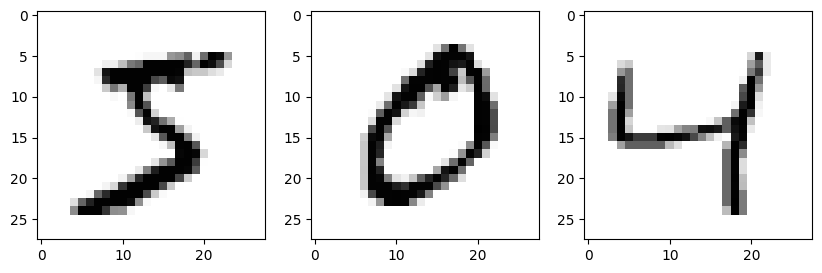

In [5]:
# Let's visualize some training samples

plt.figure(figsize = (10, 10))

plt.subplot(1,3,1)
plt.imshow(mnist_train_features[0], cmap = 'Greys')

plt.subplot(1,3,2)
plt.imshow(mnist_train_features[1], cmap = 'Greys')

plt.subplot(1,3,3)
plt.imshow(mnist_train_features[2], cmap = 'Greys')

In [6]:
# Reshape features via flattening the images
# This refers to reshape each sample from a 2d array to a 1d array.
# hint: np.reshape() function could be useful here

# Convert each 2D image (28x28) into a 1D vector (784)
mnist_train_features = mnist_train_features.reshape(mnist_train_features.shape[0], -1)
mnist_test_features = mnist_test_features.reshape(mnist_test_features.shape[0], -1)

# Print
print(mnist_train_features.shape, mnist_test_features.shape)

(1000, 784) (100, 784)


In [7]:
# Scale the dataset according to standard scaling

# Flatten training and testing images into 1D vectors
mnist_train_features = mnist_train_features.reshape(mnist_train_features.shape[0], -1)
mnist_test_features = mnist_test_features.reshape(mnist_test_features.shape[0], -1)

In [8]:
# Split training dataset into Train (90%), Validation (10%)

# Compute index corresponding to 90% of the training data
split_idx = int(0.9 * mnist_train_features.shape[0])

# Assign last 10% of data as validation features
mnist_validation_features = mnist_train_features[split_idx:]
# Assign last 10% of labels as validation targets
mnist_validation_targets = mnist_train_targets[split_idx:]

# Keep first 90% of data as training features
mnist_train_features = mnist_train_features[:split_idx]
# Keep first 90% of labels as training targets
mnist_train_targets = mnist_train_targets[:split_idx]

### Define Model

In [9]:
class mnistClassification(torch.nn.Module):

    def __init__(self, input_dim, output_dim, hidden_dim=128): # Feel free to add hidden_dim as parameters here

        super(mnistClassification, self).__init__()

        # Fully connected layers
        self.layer1 = torch.nn.Linear(input_dim, hidden_dim)
        self.layer2 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.layer3 = torch.nn.Linear(hidden_dim, output_dim)

        # Activation function
        self.relu = torch.nn.ReLU()


    def forward(self, x):

        # YOUR CODE HERE
        # Pass input through two ReLU-activated hidden layers, then output layer
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        out = self.layer3(x)

        return out

### Define Hyperparameters

In [10]:
# Initialize our neural network model with input and output dimensions
model = mnistClassification(input_dim=784, output_dim=10)


# Define the learning rate and epoch
learning_rate = 0.001
epochs = 100
# batchsize = # YOUR CODE HERE (If you are using mini-batch gradient)
# Not using mini batch gradients

# Define loss function and optimizer
loss_func = torch.nn.CrossEntropyLoss()

# Adam optimizer to update model weights using gradients
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Run this line if you have PyTorch GPU version
#if torch.cuda.is_available():
   # model.cuda()

#model

### Identify Tracked Values

In [11]:
# Placeholders for training loss and validation accuracy during training
# Training loss should be tracked for each iteration (1 iteration -> single forward pass to the network)
# Validation accuracy should be evaluated every 'Epoch' (1 epoch -> full training dataset)
# If using batch gradient, 1 iteration = 1 epoch

# Track training loss (per iteration) and validation accuracy (per epoch)
train_loss_list = []
validation_accuracy_list = []

### Train Model

In [12]:
import tqdm

# Convert the training, validation, testing dataset (NumPy arrays) into torch tensors

# Convert training features and labels from NumPy to PyTorch tensors
x_train = torch.from_numpy(mnist_train_features).float()
y_train = torch.from_numpy(mnist_train_targets).long()

# Convert validation features and labels to tensors
x_val = torch.from_numpy(mnist_validation_features).float()
y_val = torch.from_numpy(mnist_validation_targets).long()

# Convert test features and labels to tensors
x_test = torch.from_numpy(mnist_test_features).float()
y_test = torch.from_numpy(mnist_test_targets).long()


# YOUR CODE HERE

# Training Loop ---------------------------------------------------------------------------------------

for epoch in tqdm.trange(epochs):

    # YOUR CODE HERE
    # Forward pass: compute predictions and loss
    y_pred = model(x_train)
    loss = loss_func(y_pred, y_train)

    # Store training loss for tracking
    train_loss_list.append(loss.item())

    # Backpropagation and parameter update
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Compute Validation Accuracy ----------------------------------------------------------------------

    # Compute validation predictions and accuracy without updating gradients
    with torch.no_grad():
      y_val_pred = model(x_val)
      predictions = torch.argmax(y_val_pred, dim=1)
      accuracy = (predictions == y_val).float().mean().item()

      # Store validation accuracy
      validation_accuracy_list.append(accuracy)



100%|██████████| 100/100 [00:01<00:00, 62.69it/s]


### Visualize and Evaluate Model

In [13]:
# Import seaborn for prettier plots

import seaborn as sns

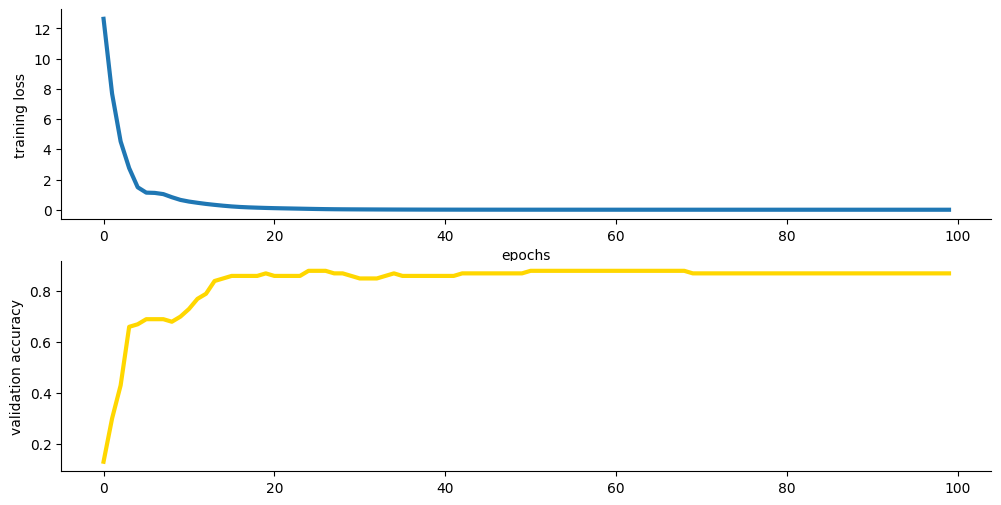

In [14]:
# Visualize training loss

plt.figure(figsize = (12, 6))

# Visualize training loss with respect to iterations (1 iteration -> single batch)
plt.subplot(2, 1, 1)
plt.plot(train_loss_list, linewidth = 3)
plt.ylabel("training loss")
plt.xlabel("epochs")
sns.despine()

# Visualize validation accuracy with respect to epochs
plt.subplot(2, 1, 2)
plt.plot(validation_accuracy_list, linewidth = 3, color = 'gold')
plt.ylabel("validation accuracy")
sns.despine()

In [15]:
# Compute the testing accuracy

# Evaluate model on test data and compute accuracy
with torch.no_grad():
  y_test_pred = model(x_test)
  test_predictions = torch.argmax(y_test_pred, dim=1)
  test_accuracy = (test_predictions == y_test).float().mean().item()

# Print accuracy
print("Testing Accuracy:", test_accuracy)

Testing Accuracy: 0.9100000262260437


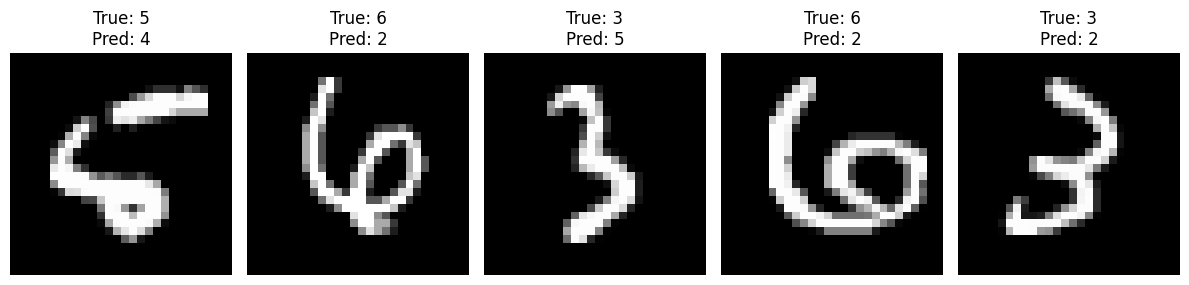

In [16]:
# Plot 5 incorrectly classified testing samples and print the model predictions for each of them
# You can use np.reshape() to convert flattened 1D array back to 2D array

# YOUR CODE HERE
with torch.no_grad():
  # Forward pass on test data to get predictions
  y_test_pred = model(x_test)
  test_predictions = torch.argmax(y_test_pred, dim=1)

  # Find indices where predictions do not match true labels
  incorrect_indices = (test_predictions != y_test).nonzero(as_tuple=True)[0]

  # Create a figure to display misclassified images
  plt.figure(figsize=(12,8))

  # Loop through up to 5 incorrect predictions
  for i in range(min(5, len(incorrect_indices))):
    idx = incorrect_indices[i].item()

    # Reshape flattened image back to 28x28 for visualization
    image = mnist_test_features[idx].reshape(28, 28)

    # Retrieve true and predicted labels
    true_label = y_test[idx].item()
    predicted_label = test_predictions[idx].item()

    # Plot image with labels
    plt.subplot(1, 5, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"True: {true_label}\nPred: {predicted_label}")
    plt.axis('off')


# Adjust layout and display plots
plt.tight_layout()
plt.show()